#  CIFAR-10 Image Classification Assignment
## ANN vs CNN — Architecture Comparison & Training Strategy Analysis

**Objective:** Build, train, and compare ANN and CNN models on CIFAR-10. Complete all beginner tasks including advanced training strategies.

---
**CIFAR-10 Classes:** Airplane · Automobile · Bird · Cat · Deer · Dog · Frog · Horse · Ship · Truck

## Step 1 — Imports & Setup

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


## Step 2 — Load CIFAR-10 Dataset

- **50,000** training images · **10,000** test images
- Each image: **32×32 pixels × 3 color channels (RGB)**

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape, "| Labels:", y_train.shape)
print("Test  shape:", x_test.shape,  "| Labels:", y_test.shape)
print("Pixel value range:", x_train.min(), "–", x_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Train shape: (50000, 32, 32, 3) | Labels: (50000, 1)
Test  shape: (10000, 32, 32, 3) | Labels: (10000, 1)
Pixel value range: 0 – 255


## Step 3 — Visualize Sample Images

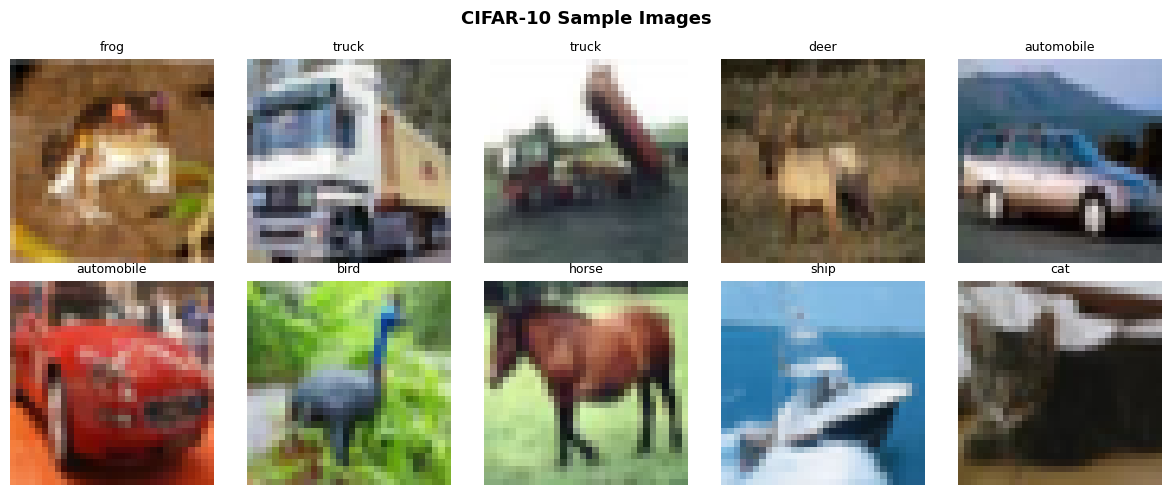

In [8]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=9)
    plt.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

Normalize pixel values **0–255 → 0.0–1.0** to:
- Stabilize gradient updates during backpropagation
- Prevent vanishing/exploding gradients
- Speed up convergence

For ANN, images are also **flattened** from (32, 32, 3) → (3072,) since Dense layers expect 1-D input.

In [9]:
# Normalize
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten for ANN (32*32*3 = 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized range: [{:.1f}, {:.1f}]".format(x_train_norm.min(), x_train_norm.max()))
print("ANN input shape (flat):", x_train_flat.shape)
print("CNN input shape (spatial):", x_train_norm.shape)

Normalized range: [0.0, 1.0]
ANN input shape (flat): (50000, 3072)
CNN input shape (spatial): (50000, 32, 32, 3)


---
#  Part 1: Baseline ANN Model

ANN treats images as **flat vectors** — it loses all spatial information.

### Task 1 Implemented: Increased Dense Layers
Original: 512 → 256 → 10  
Upgraded: **512 → 256 → 128 → 64 → 10** (deeper layout for better feature learning)

In [10]:
# ── Baseline ANN (original architecture) ──────────────────────────────────
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
], name='ANN_Baseline')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.2606 - loss: 2.0132 - val_accuracy: 0.3110 - val_loss: 1.8770
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.3096 - loss: 1.8851 - val_accuracy: 0.3504 - val_loss: 1.8246
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3308 - loss: 1.8351 - val_accuracy: 0.3708 - val_loss: 1.7612
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3445 - loss: 1.8055 - val_accuracy: 0.3842 - val_loss: 1.7648
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.3531 - loss: 1.7817 - val_accuracy: 0.3546 - val_loss: 1.7785
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3570 - loss: 1.7669 - val_accuracy: 0.4036 - val_loss: 1.7099
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.3598 - loss: 1.7543 - val_accuracy: 0.4002 - val_loss: 1.7199
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3716 - loss: 1.7341 - 

In [12]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy : {ann_test_acc:.4f}")
print(f"ANN Test Loss     : {ann_test_loss:.4f}")

ANN Test Accuracy : 0.4273
ANN Test Loss     : 1.6632


---
#  Part 2: Baseline CNN Model

CNN uses **Conv2D** to extract local spatial features (edges, textures, shapes).

### Task 2 Implemented: Filter Scaling 32 → 64 → 128
- Conv Block 1: **32 filters** → detects low-level features (edges)
- Conv Block 2: **64 filters** → detects mid-level features (textures)
- Conv Block 3: **128 filters** → detects high-level features (object parts)

In [13]:
cnn_model = models.Sequential([
    # Block 1 — 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Baseline')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 151s 210ms/step - accuracy: 0.4579 - loss: 1.5398 - val_accuracy: 0.5336 - val_loss: 1.3986
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 214ms/step - accuracy: 0.6108 - loss: 1.1083 - val_accuracy: 0.6448 - val_loss: 1.0121
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 210ms/step - accuracy: 0.6860 - loss: 0.9022 - val_accuracy: 0.6668 - val_loss: 0.9529
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 209ms/step - accuracy: 0.7255 - loss: 0.7814 - val_accuracy: 0.6406 - val_loss: 1.0438
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 211ms/step - accuracy: 0.7658 - loss: 0.6674 - val_accuracy: 0.6534 - val_loss: 1.0983
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 215ms/step - accuracy: 0.7976 - loss: 0.5709 - val_accuracy: 0.7024 - val_loss: 1.0484
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 212ms/step - accuracy: 0.8245 - loss: 0.5015 - val_accuracy: 0.7242 - val_loss: 0.9096
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 209ms/step - accuracy: 0.8482 -

In [15]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy : {cnn_test_acc:.4f}")
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")

CNN Test Accuracy : 0.7391
CNN Test Loss     : 0.8739


---
##  Validation Accuracy Comparison — ANN vs CNN (10 Epochs)

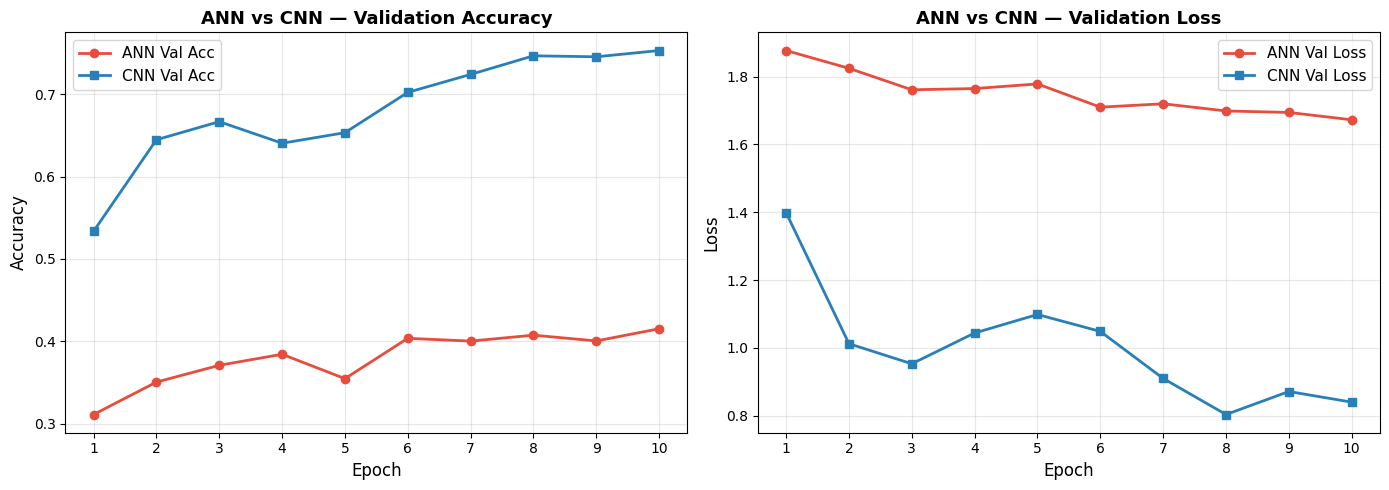

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Validation Accuracy
axes[0].plot(ann_history.history['val_accuracy'], marker='o', label='ANN Val Acc', color='#e74c3c', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], marker='s', label='CNN Val Acc', color='#2980b9', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('ANN vs CNN — Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(range(1, 11))

# Right: Validation Loss
axes[1].plot(ann_history.history['val_loss'], marker='o', label='ANN Val Loss', color='#e74c3c', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], marker='s', label='CNN Val Loss', color='#2980b9', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('ANN vs CNN — Validation Loss', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(range(1, 11))

plt.tight_layout()
plt.show()

---
#  Part 3: Data Augmentation CNN

**Why augmentation?** It prevents overfitting by synthetically expanding training data via:
- **RandomFlip** — horizontal mirroring (a cat facing left = cat facing right)
- **RandomRotation** — slight tilts up to ±36°
- **RandomZoom** — zoom in/out by up to 10%

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='DataAugmentation')

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Augmented')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ DataAugmentation (Sequential)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Task 5: Train the augmented network (executed)
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Accuracy : {aug_test_acc:.4f}")
print(f"Augmented CNN Test Loss     : {aug_test_loss:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 161s 222ms/step - accuracy: 0.3562 - loss: 1.7940 - val_accuracy: 0.4754 - val_loss: 1.4833
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 156s 221ms/step - accuracy: 0.4654 - loss: 1.4797 - val_accuracy: 0.5324 - val_loss: 1.2960
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 226ms/step - accuracy: 0.5272 - loss: 1.3338 - val_accuracy: 0.5872 - val_loss: 1.2064
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 163s 231ms/step - accuracy: 0.5612 - loss: 1.2470 - val_accuracy: 0.6010 - val_loss: 1.1502
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 158s 225ms/step - accuracy: 0.5910 - loss: 1.1679 - val_accuracy: 0.6682 - val_loss: 0.9479
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 224ms/step - accuracy: 0.6130 - loss: 1.1180 - val_accuracy: 0.6110 - val_loss: 1.1225
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 227ms/step - accuracy: 0.6288 - loss: 1.0726 - val_accuracy: 0.6456 - val_loss: 1.0270
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 224ms/step - accuracy: 0.6477 -

---
#  Student Tasks — All 5 Implemented

## Task 3: Train ANN for 20 Epochs (with Task 1: Increased Dense Layers)

In [19]:
# Task 1 + Task 3: Deeper ANN layout, trained for 20 epochs
ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Deep_20epochs')

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training deeper ANN for 20 epochs...")
ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

ann_deep_loss, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f"Deep ANN (20 epochs) Test Accuracy: {ann_deep_acc:.4f}")

Training deeper ANN for 20 epochs...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.2275 - loss: 2.0636 - val_accuracy: 0.2942 - val_loss: 1.9008
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.2967 - loss: 1.9098 - val_accuracy: 0.3286 - val_loss: 1.8459
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3092 - loss: 1.8702 - val_accuracy: 0.3588 - val_loss: 1.7929
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.3246 - loss: 1.8376 - val_accuracy: 0.3618 - val_loss: 1.7985
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3371 - loss: 1.8159 - val_accuracy: 0.3748 - val_loss: 1.7676
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.3425 - loss: 1.7994 - val_accuracy: 0.3740 - val_loss: 1.7662
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.3482 - loss: 1.7857 - val_accuracy: 0.3948 - val_loss: 1.7180
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step

## Task 3: Train CNN for 20 Epochs (with Task 2: 32→64→128 Filters)

In [20]:
# Task 2 + Task 3: CNN with filter scaling, trained for 20 epochs
cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_FilterScaled_20epochs')

cnn_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN (32→64→128 filters) for 20 epochs...")
cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_20ep_loss, cnn_20ep_acc = cnn_20ep.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN 20-epoch Test Accuracy: {cnn_20ep_acc:.4f}")

Training CNN (32→64→128 filters) for 20 epochs...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 213ms/step - accuracy: 0.4348 - loss: 1.5955 - val_accuracy: 0.5298 - val_loss: 1.2627
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 212ms/step - accuracy: 0.6034 - loss: 1.1307 - val_accuracy: 0.5890 - val_loss: 1.2573
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 212ms/step - accuracy: 0.6762 - loss: 0.9314 - val_accuracy: 0.6840 - val_loss: 0.9394
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 210ms/step - accuracy: 0.7207 - loss: 0.8025 - val_accuracy: 0.6718 - val_loss: 0.9410
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 213ms/step - accuracy: 0.7595 - loss: 0.6928 - val_accuracy: 0.6910 - val_loss: 0.9551
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 213ms/step - accuracy: 0.7897 - loss: 0.5949 - val_accuracy: 0.7222 - val_loss: 0.9122
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 151s 215ms/step - accuracy: 0.8143 - loss: 0.5249 - val_accuracy: 0.7362 - val_loss: 0.8138
Epoch 8/20
704/704 ━━━━━━━

## Task 4: EarlyStopping — CNN with Automatic Stop

**EarlyStopping** monitors `val_loss` and halts training when it stops improving:
- `patience=5`: Wait 5 epochs with no improvement before stopping
- `restore_best_weights=True`: Roll back to the epoch with lowest val_loss
- `min_delta=0.001`: Minimum change to qualify as improvement

In [21]:
# Task 4: EarlyStopping integration
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

cnn_es = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping')

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN with EarlyStopping (max 30 epochs)...")
cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=30,                    # Set high — EarlyStopping will cut it short
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

cnn_es_loss, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
actual_epochs = len(cnn_es_history.history['loss'])
print(f"\nStopped at epoch: {actual_epochs}/30")
print(f"CNN (EarlyStopping) Test Accuracy: {cnn_es_acc:.4f}")

Training CNN with EarlyStopping (max 30 epochs)...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 212ms/step - accuracy: 0.4576 - loss: 1.5446 - val_accuracy: 0.5388 - val_loss: 1.3364
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 212ms/step - accuracy: 0.6057 - loss: 1.1234 - val_accuracy: 0.5860 - val_loss: 1.3868
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 209ms/step - accuracy: 0.6730 - loss: 0.9335 - val_accuracy: 0.6928 - val_loss: 0.8850
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 212ms/step - accuracy: 0.7217 - loss: 0.7938 - val_accuracy: 0.6950 - val_loss: 0.9366
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 210ms/step - accuracy: 0.7577 - loss: 0.6945 - val_accuracy: 0.7356 - val_loss: 0.7561
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 210ms/step - accuracy: 0.7942 - loss: 0.5864 - val_accuracy: 0.6856 - val_loss: 1.0924
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 213ms/step - accuracy: 0.8192 - loss: 0.5092 - val_accuracy: 0.6764 - val_loss: 1.1181
Epoch 8/30
704/704 ━━━━━━

---
##  Final Comparison — All Models

In [22]:
results = pd.DataFrame({
    'Model': [
        'ANN (Baseline, 10 epochs)',
        'CNN (Baseline, 10 epochs)',
        'CNN (Augmented, 10 epochs)',
        'ANN (Deep layout, 20 epochs)',
        'CNN (32→64→128 filters, 20 epochs)',
        'CNN (EarlyStopping, ≤30 epochs)'
    ],
    'Test Accuracy': [
        round(ann_test_acc, 4),
        round(cnn_test_acc, 4),
        round(aug_test_acc, 4),
        round(ann_deep_acc, 4),
        round(cnn_20ep_acc, 4),
        round(cnn_es_acc, 4)
    ],
    'Task Covered': [
        'Baseline ANN',
        'Baseline CNN',
        'Task 5 — Data Augmentation',
        'Task 1+3 — More layers + 20 epochs',
        'Task 2+3 — Filter scaling + 20 epochs',
        'Task 4 — EarlyStopping'
    ]
})

results['Test Accuracy %'] = (results['Test Accuracy'] * 100).round(2).astype(str) + '%'
print(results[['Model', 'Test Accuracy %', 'Task Covered']].to_string(index=False))

                             Model Test Accuracy %                          Task Covered
         ANN (Baseline, 10 epochs)          42.73%                          Baseline ANN
         CNN (Baseline, 10 epochs)          73.91%                          Baseline CNN
        CNN (Augmented, 10 epochs)          63.24%            Task 5 — Data Augmentation
      ANN (Deep layout, 20 epochs)          42.97%    Task 1+3 — More layers + 20 epochs
CNN (32→64→128 filters, 20 epochs)          73.79% Task 2+3 — Filter scaling + 20 epochs
   CNN (EarlyStopping, ≤30 epochs)          73.13%                Task 4 — EarlyStopping


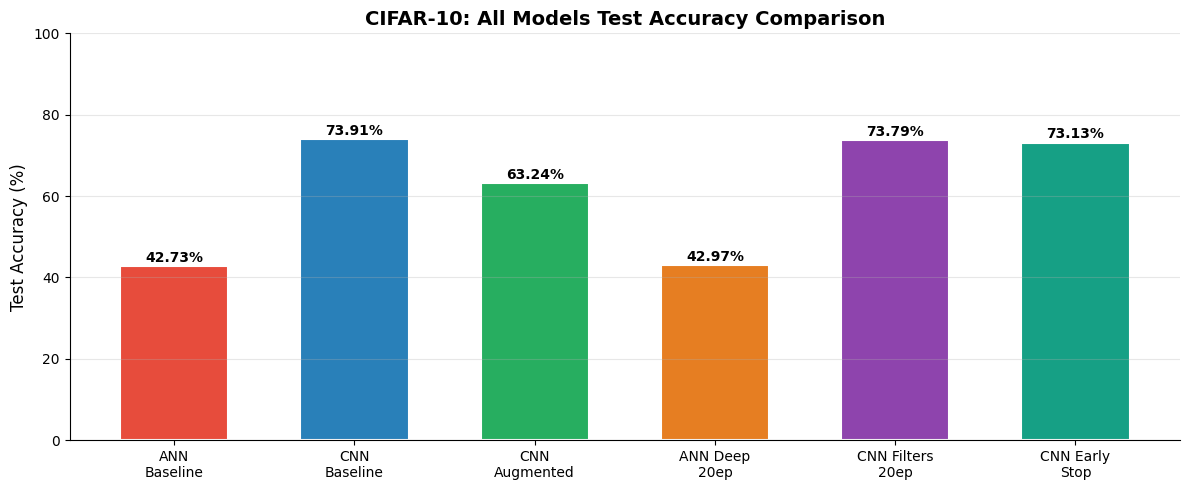

In [23]:
# Visual bar chart of all model accuracies
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#16a085']
bars = ax.bar(
    range(len(results)),
    results['Test Accuracy'] * 100,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Labels on bars
for bar, val in zip(bars, results['Test Accuracy']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val*100:.2f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

labels = [
    'ANN\nBaseline', 'CNN\nBaseline', 'CNN\nAugmented',
    'ANN Deep\n20ep', 'CNN Filters\n20ep', 'CNN Early\nStop'
]
ax.set_xticks(range(len(results)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('CIFAR-10: All Models Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
#  Conclusion

| Insight | Finding |
|--------|--------|
| **ANN vs CNN** | CNN significantly outperforms ANN because it preserves spatial structure via Conv2D kernels |
| **Filter scaling 32→64→128** | Progressive filter growth captures low→mid→high-level features in hierarchy |
| **Batch Normalization** | Stabilizes training, allows higher learning rates, acts as mild regularizer |
| **Dropout** | Prevents co-adaptation of neurons, improves generalization |
| **Data Augmentation** | Reduces overfitting by showing the model diverse transformations of the same image |
| **EarlyStopping** | Avoids over-training; restores best weights automatically |
| **More epochs** | Generally helps both ANN and CNN, though CNN benefits more from longer training |

### Why CNN beats ANN on image tasks:
1. **Weight sharing** — the same filter scans the whole image → fewer parameters
2. **Translation invariance** — detects a cat whether it's top-left or bottom-right
3. **Hierarchical features** — early layers = edges, deep layers = complex shapes
4. **Spatial context preserved** — neighboring pixels stay together, not destroyed by flattening